# Batting Order Exploration

**Goal:** figure out whether real MLB lineup data contains patterns we can learn from to recommend a batting order in our IDSS.

**Data:** `batting.csv` — one row per player per game (Retrosheet-style), including:
- `b_lp` — the **lineup position (1–9)** the player batted in
- `b_seq` — appearance sequence in that slot (1 = starter)
- per-game counting stats (`b_pa`, `b_ab`, `b_h`, `b_hr`, `b_w`, `b_k`, `b_sb`, ...)

**Questions:**
1. Do lineup slots have distinct skill profiles (e.g., does the #3 hitter really hit for the most power)?
2. Does clustering players by skill recover "lineup roles"?
3. How predictable is a player's slot from their stats alone?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.facecolor"] = "white"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

USECOLS = [
    "gid", "id", "b_lp", "b_seq", "gametype", "date",
    "b_pa", "b_ab", "b_r", "b_h", "b_d", "b_t", "b_hr", "b_rbi",
    "b_sf", "b_hbp", "b_w", "b_k", "b_sb", "b_cs",
]

df = pd.read_csv("batting.csv", usecols=USECOLS, low_memory=False)
print(f"Raw rows: {len(df):,}")
df.head()

Raw rows: 5,746,328


,gid,id,b_lp,b_seq,b_pa,b_ab,b_r,b_h,b_d,b_t,b_hr,b_rbi,b_sf,b_hbp,b_w,b_k,b_sb,b_cs,date,gametype
0,CIN189804150,burkj101,1.0,1.0,4.0,4.0,0.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,18980415,regular
1,CIN189804150,mckee101,2.0,1.0,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,18980415,regular
2,CIN189804150,chilc101,3.0,1.0,4.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,NaN,18980415,regular
3,CIN189804150,wallb101,4.0,1.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,18980415,regular
4,CIN189804150,mcalj102,5.0,1.0,4.0,3.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,NaN,18980415,regular


In [2]:
# Clean: regular-season starters only (b_seq == 1 means they started the game in that slot),
# valid lineup slots 1-9, and modern era (lineup construction norms changed a lot over 100 years).
df["year"] = df["date"] // 10000

starters = df[
    (df["gametype"] == "regular")
    & (df["b_seq"] == 1)
    & (df["b_lp"].between(1, 9))
    & (df["year"] >= 2000)
].copy()

stat_cols = ["b_pa", "b_ab", "b_r", "b_h", "b_d", "b_t", "b_hr",
             "b_rbi", "b_sf", "b_hbp", "b_w", "b_k", "b_sb", "b_cs"]
starters[stat_cols] = starters[stat_cols].fillna(0)

print(f"Starter rows (2000+): {len(starters):,}")
print(f"Unique games: {starters['gid'].nunique():,}")
print(f"Unique players: {starters['id'].nunique():,}")
starters["b_lp"].value_counts().sort_index()

Starter rows (2000+): 1,109,304
Unique games: 61,628
Unique players: 4,603


b_lp
1.0    123256
2.0    123256
3.0    123256
4.0    123256
5.0    123256
6.0    123256
7.0    123256
8.0    123256
9.0    123256
Name: count, dtype: int64

## Build player-season profiles

One row per (player, season): total counting stats, rate stats (OBP, SLG, ISO, BB%, K%, SB per game), and the **primary lineup slot** they batted in that season. We keep player-seasons with enough starts and a stable slot so the "slot label" is meaningful.

In [3]:
agg = (
    starters.groupby(["id", "year"])
    .agg(
        games=("gid", "nunique"),
        pa=("b_pa", "sum"), ab=("b_ab", "sum"), r=("b_r", "sum"),
        h=("b_h", "sum"), d2=("b_d", "sum"), t3=("b_t", "sum"),
        hr=("b_hr", "sum"), rbi=("b_rbi", "sum"), sf=("b_sf", "sum"),
        hbp=("b_hbp", "sum"), bb=("b_w", "sum"), k=("b_k", "sum"),
        sb=("b_sb", "sum"), cs=("b_cs", "sum"),
    )
    .reset_index()
)

# Primary slot = the slot the player started in most often that season, plus its share of starts
slot_counts = (
    starters.groupby(["id", "year", "b_lp"]).size().rename("n").reset_index()
)
primary = slot_counts.loc[slot_counts.groupby(["id", "year"])["n"].idxmax()]
primary["slot_share"] = primary["n"] / primary.groupby(["id", "year"])["n"].transform("sum")
primary = primary.merge(
    slot_counts.groupby(["id", "year"])["n"].sum().rename("starts").reset_index(),
    on=["id", "year"],
)
primary["slot_share"] = primary["n"] / primary["starts"]
players = agg.merge(
    primary[["id", "year", "b_lp", "slot_share", "starts"]], on=["id", "year"]
).rename(columns={"b_lp": "slot"})

# Rate stats
singles = players["h"] - players["d2"] - players["t3"] - players["hr"]
tb = singles + 2 * players["d2"] + 3 * players["t3"] + 4 * players["hr"]
obp_den = players["ab"] + players["bb"] + players["hbp"] + players["sf"]
players["avg"] = players["h"] / players["ab"]
players["obp"] = (players["h"] + players["bb"] + players["hbp"]) / obp_den
players["slg"] = tb / players["ab"]
players["ops"] = players["obp"] + players["slg"]
players["iso"] = players["slg"] - players["avg"]  # raw power
players["bb_rate"] = players["bb"] / players["pa"]
players["k_rate"] = players["k"] / players["pa"]
players["sb_pg"] = players["sb"] / players["games"]  # speed proxy

# Keep regulars with a stable slot: >= 80 starts, >= 50% of starts in their primary slot
regulars = players[(players["starts"] >= 80) & (players["slot_share"] >= 0.5)].copy()
print(f"Player-seasons total: {len(players):,}")
print(f"Regulars w/ stable slot: {len(regulars):,}")
regulars.groupby("slot").size()

Player-seasons total: 20,975
Regulars w/ stable slot: 3,296


slot
1.0    669
2.0    519
3.0    596
4.0    556
5.0    280
6.0    154
7.0    112
8.0    223
9.0    187
dtype: int64

## Question 1 — Do lineup slots have distinct skill profiles?

If managers assign slots based on skills, the average profile per slot should differ in systematic ways (leadoff = on-base + speed, #3/#4 = power, #8/#9 = weakest bats).

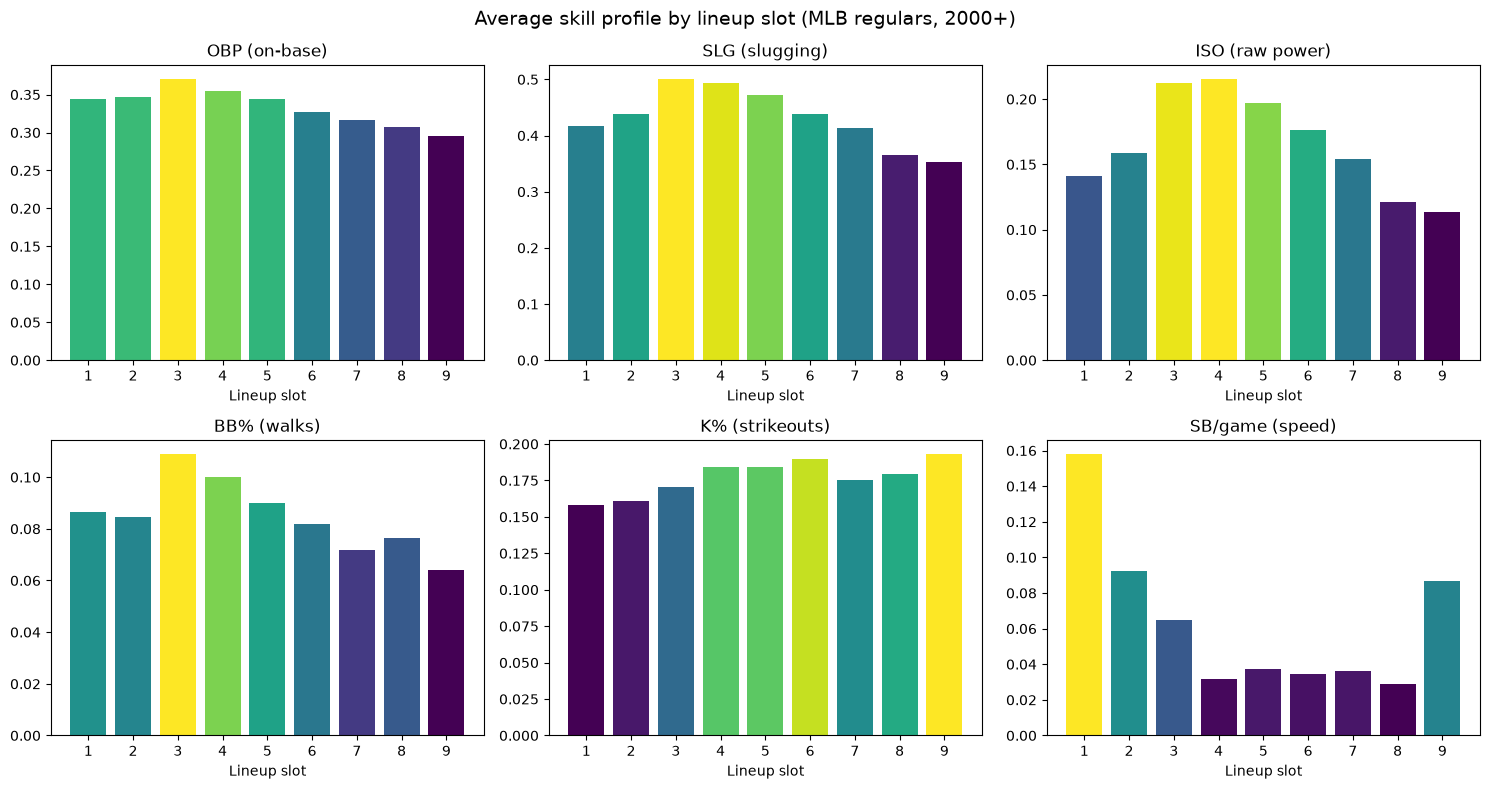

In [4]:
FEATURES = ["obp", "slg", "iso", "bb_rate", "k_rate", "sb_pg"]
LABELS = {
    "obp": "OBP (on-base)", "slg": "SLG (slugging)", "iso": "ISO (raw power)",
    "bb_rate": "BB% (walks)", "k_rate": "K% (strikeouts)", "sb_pg": "SB/game (speed)",
}

slot_profile = regulars.groupby("slot")[FEATURES].mean()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, FEATURES):
    vals = slot_profile[feat]
    colors = plt.cm.viridis((vals - vals.min()) / (vals.max() - vals.min()))
    ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(LABELS[feat])
    ax.set_xlabel("Lineup slot")
    ax.set_xticks(range(1, 10))
fig.suptitle("Average skill profile by lineup slot (MLB regulars, 2000+)", fontsize=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "slot_profiles.png", dpi=110, bbox_inches="tight")
plt.show()

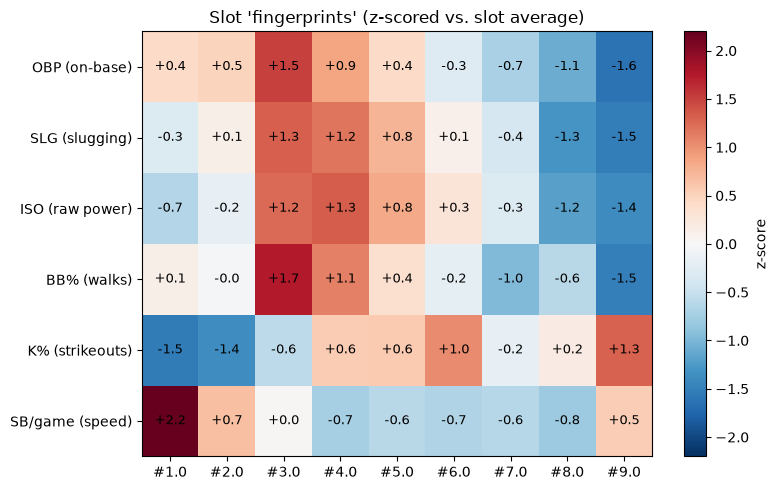

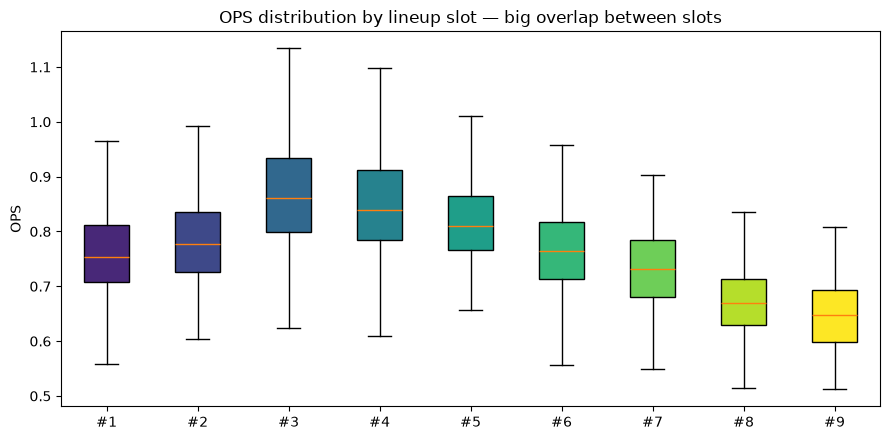

In [5]:
# Same idea as a heatmap of z-scores: how each slot deviates from the average hitter.
z = (slot_profile - slot_profile.mean()) / slot_profile.std()

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(z.T.values, cmap="RdBu_r", vmin=-2.2, vmax=2.2, aspect="auto")
ax.set_xticks(range(9), labels=[f"#{s}" for s in z.index])
ax.set_yticks(range(len(FEATURES)), labels=[LABELS[f] for f in FEATURES])
for i in range(len(FEATURES)):
    for j in range(9):
        ax.text(j, i, f"{z.T.values[i, j]:+.1f}", ha="center", va="center", fontsize=9)
ax.set_title("Slot 'fingerprints' (z-scored vs. slot average)")
fig.colorbar(im, label="z-score")
fig.tight_layout()
fig.savefig(FIG_DIR / "slot_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

# OPS spread within each slot — overlap matters for how learnable this is
fig, ax = plt.subplots(figsize=(9, 4.5))
data = [regulars.loc[regulars["slot"] == s, "ops"].values for s in range(1, 10)]
bp = ax.boxplot(data, tick_labels=[f"#{s}" for s in range(1, 10)], showfliers=False, patch_artist=True)
for patch, s in zip(bp["boxes"], range(1, 10)):
    patch.set_facecolor(plt.cm.viridis(s / 9))
ax.set_ylabel("OPS")
ax.set_title("OPS distribution by lineup slot — big overlap between slots")
fig.tight_layout()
fig.savefig(FIG_DIR / "ops_by_slot.png", dpi=110, bbox_inches="tight")
plt.show()

## Question 2 — Does clustering recover "lineup roles"?

Your idea: cluster players by skill and map clusters to batting-order positions. Let's test it — KMeans on the standardized skill features, then check how each cluster's members are actually distributed across lineup slots.

           obp    slg    iso  bb_rate  k_rate  sb_pg    ops
cluster                                                    
0        0.332  0.459  0.201    0.091   0.238  0.053  0.791
1        0.358  0.465  0.176    0.089   0.140  0.053  0.823
2        0.307  0.367  0.114    0.065   0.158  0.050  0.674
3        0.399  0.559  0.261    0.136   0.179  0.059  0.957
4        0.341  0.396  0.116    0.079   0.145  0.253  0.737


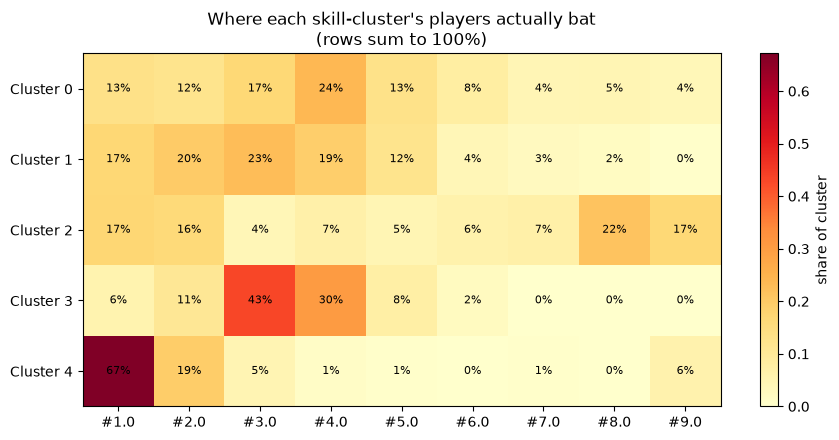

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(regulars[FEATURES])

km = KMeans(n_clusters=5, n_init=10, random_state=42)
regulars["cluster"] = km.fit_predict(X)

# Describe each cluster by its mean profile so we can name the "roles"
cluster_profile = regulars.groupby("cluster")[FEATURES + ["ops"]].mean().round(3)
print(cluster_profile)

# How does each cluster spread across actual lineup slots?
ct = pd.crosstab(regulars["cluster"], regulars["slot"], normalize="index")

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(ct.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(9), labels=[f"#{s}" for s in ct.columns])
ax.set_yticks(range(len(ct)), labels=[f"Cluster {c}" for c in ct.index])
for i in range(len(ct)):
    for j in range(9):
        ax.text(j, i, f"{ct.values[i, j]:.0%}", ha="center", va="center", fontsize=8)
ax.set_title("Where each skill-cluster's players actually bat\n(rows sum to 100%)")
fig.colorbar(im, label="share of cluster")
fig.tight_layout()
fig.savefig(FIG_DIR / "cluster_vs_slot.png", dpi=110, bbox_inches="tight")
plt.show()

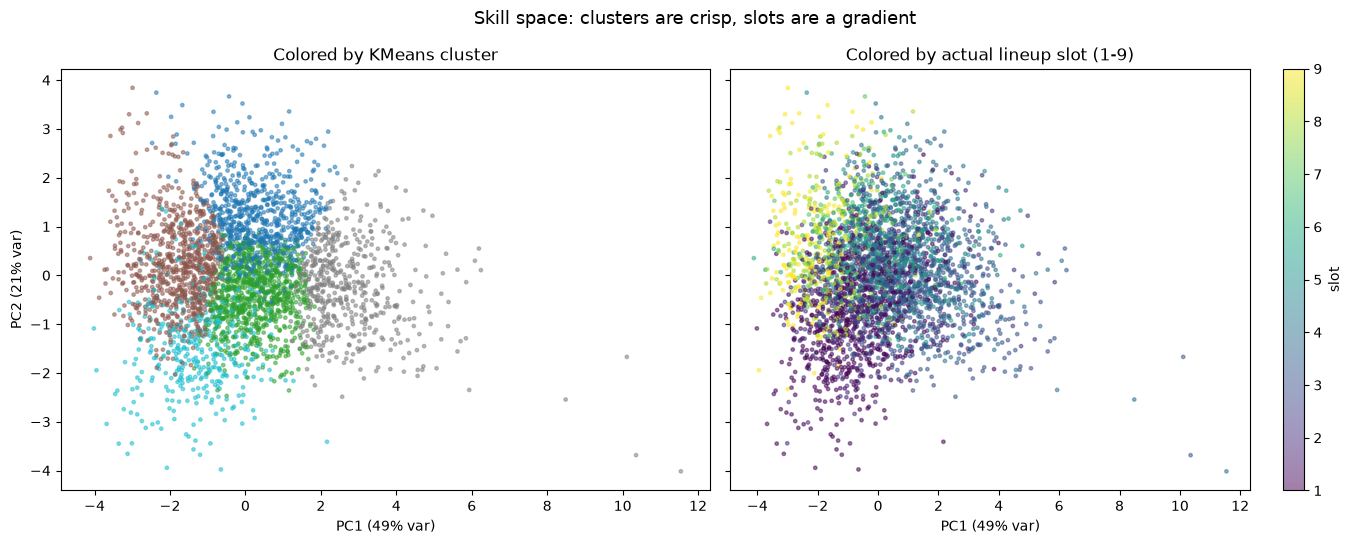

In [7]:
# PCA projection: color by cluster (left) vs. by actual slot (right).
# If slots were cleanly separated skill-groups, the right plot would show distinct color bands.
pca = PCA(n_components=2, random_state=42)
P = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
sc0 = axes[0].scatter(P[:, 0], P[:, 1], c=regulars["cluster"], cmap="tab10", s=6, alpha=0.5)
axes[0].set_title("Colored by KMeans cluster")
sc1 = axes[1].scatter(P[:, 0], P[:, 1], c=regulars["slot"], cmap="viridis", s=6, alpha=0.5)
axes[1].set_title("Colored by actual lineup slot (1-9)")
for ax in axes:
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)")
fig.colorbar(sc1, ax=axes[1], label="slot")
fig.suptitle("Skill space: clusters are crisp, slots are a gradient", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "pca_clusters_slots.png", dpi=110, bbox_inches="tight")
plt.show()

## Question 3 — How predictable is a player's slot from stats alone?

Train a classifier (stats → slot). Exact-slot accuracy tells us how deterministic the mapping is; "within 1 slot" accuracy tells us whether the *ordering* signal is strong even when the exact slot isn't.

Exact-slot accuracy:    37.0%  (random guess = 11.1%)
Within-one-slot:        67.1%


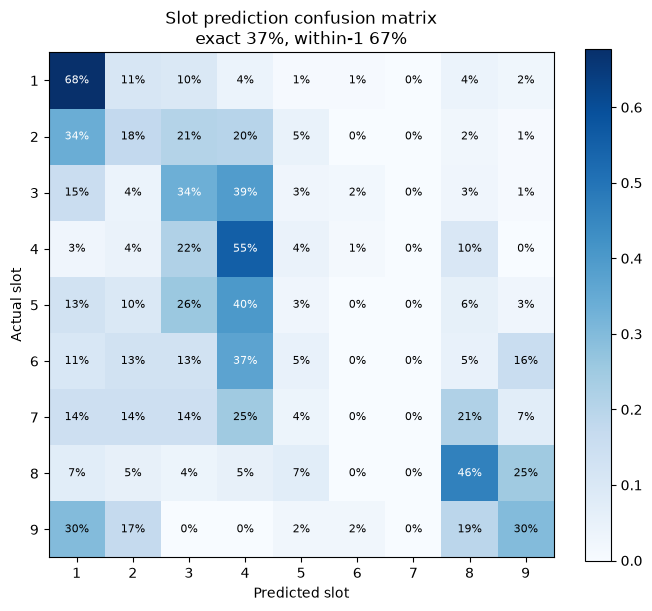

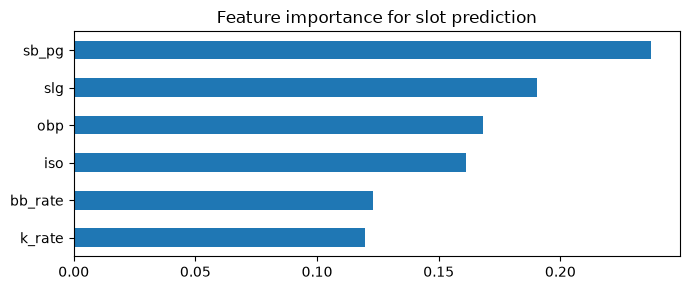

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

X_tr, X_te, y_tr, y_te = train_test_split(
    regulars[FEATURES], regulars["slot"], test_size=0.25,
    random_state=42, stratify=regulars["slot"],
)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_te)

exact = (pred == y_te).mean()
within1 = (np.abs(pred - y_te) <= 1).mean()
print(f"Exact-slot accuracy:    {exact:.1%}  (random guess = 11.1%)")
print(f"Within-one-slot:        {within1:.1%}")

cm = confusion_matrix(y_te, pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(9), labels=range(1, 10))
ax.set_yticks(range(9), labels=range(1, 10))
ax.set_xlabel("Predicted slot")
ax.set_ylabel("Actual slot")
for i in range(9):
    for j in range(9):
        ax.text(j, i, f"{cm[i, j]:.0%}", ha="center", va="center",
                fontsize=8, color="white" if cm[i, j] > 0.3 else "black")
ax.set_title(f"Slot prediction confusion matrix\nexact {exact:.0%}, within-1 {within1:.0%}")
fig.colorbar(im)
fig.tight_layout()
fig.savefig(FIG_DIR / "confusion_matrix.png", dpi=110, bbox_inches="tight")
plt.show()

pd.Series(rf.feature_importances_, index=FEATURES).sort_values().plot.barh(
    figsize=(7, 3), title="Feature importance for slot prediction")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

## Takeaways for the IDSS

1. **Slots do have distinct average profiles** — leadoff hitters have the most speed and strong OBP, #3–#4 have the most power, #7–#9 are the weakest bats. The data confirms the folk wisdom.
2. **But slots are a gradient, not clusters.** The PCA plot shows slot varies smoothly through skill space, and exact-slot prediction tops out low even with 20k+ labeled player-seasons — managers use overall quality ordering plus soft role preferences, not hard categories.
3. **Clustering alone can't output an order** (a cluster of 3 power hitters can't all bat 3rd — someone must bat 4th and 5th).

**Recommended model:** learn a **prototype profile for each of the 9 slots** from this data (the slot-profile table above). For a user's roster, build a 9×9 score matrix `fit[player, slot] = similarity(player_profile, slot_prototype)` and solve it with the **Hungarian algorithm** (`scipy.optimize.linear_sum_assignment`) — exactly the same machinery as our defensive-position assignment, and it naturally supports locked slots. Clustering stays useful as an *explanation* layer ("Josh profiles like a classic leadoff hitter").